# Model 2: Autoencoder - MNIST Image Reconstruction

## 1. Problem Definition

**Aim of the application:** Train an Autoencoder to learn a compact latent representation of handwritten digit images (MNIST) and reconstruct the original images from that compressed representation.

**Type of data used:** Image data (28×28 grayscale images of handwritten digits, 0–9).

**Type of problem:** Unsupervised representation learning / image reconstruction. No class labels are used during training - the model learns to compress and reconstruct the input itself.

**Why Autoencoder is suitable for this problem:**  
An Autoencoder is specifically designed to learn efficient low-dimensional encodings of input data through an encoder-decoder architecture trained with reconstruction loss. Unlike supervised models, it does not require labeled data. The MNIST dataset provides clean, standardized images that make it an ideal benchmark for evaluating reconstruction quality visually and quantitatively. The learned latent space also has practical applications in anomaly detection, denoising, and dimensionality reduction.

## 2. Dataset

**Name:** MNIST Handwritten Digits Dataset  
**Link:** http://yann.lecun.com/exdb/mnist/ (also available via `tensorflow.keras.datasets.mnist`)  
**Type:** Grayscale image dataset  
**Size:** 70,000 images (60,000 train / 10,000 test), 28×28 pixels, 10 classes (digits 0–9)

**Why this dataset is suitable:**  
MNIST is the canonical benchmark dataset for image-based deep learning tasks. Its simple, uniform structure (centered digits on white background, consistent size) makes it ideal for validating that the Autoencoder architecture and reconstruction loss are working correctly. The visual nature of the reconstructions provides immediate, intuitive feedback on model quality.

**Basic preprocessing steps:**
- Load from `keras.datasets.mnist`
- Normalize pixel values from [0, 255] to [0.0, 1.0]
- Flatten each 28×28 image to a 784-dimensional vector (for dense autoencoder)
- Labels are not used - this is fully unsupervised training

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow version: {tf.__version__}')
np.random.seed(42)
tf.random.set_seed(42)

/Users/rayandughmoush/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


## 3. Data Loading and Preprocessing

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

print(f'Train set shape: {X_train_raw.shape}')
print(f'Test set shape:  {X_test_raw.shape}')
print(f'Pixel value range before normalization: [{X_train_raw.min()}, {X_train_raw.max()}]')

# Normalize to [0, 1] and flatten to 784-dimensional vectors
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

print(f'\nAfter preprocessing:')
print(f'Train shape: {X_train_flat.shape}')
print(f'Test shape:  {X_test_flat.shape}')
print(f'Pixel value range after normalization: [{X_train_flat.min():.1f}, {X_train_flat.max():.1f}]')

Train set shape: (60000, 28, 28)
Test set shape:  (10000, 28, 28)
Pixel value range before normalization: [0, 255]

After preprocessing:
Train shape: (60000, 784)
Test shape:  (10000, 784)
Pixel value range after normalization: [0.0, 1.0]


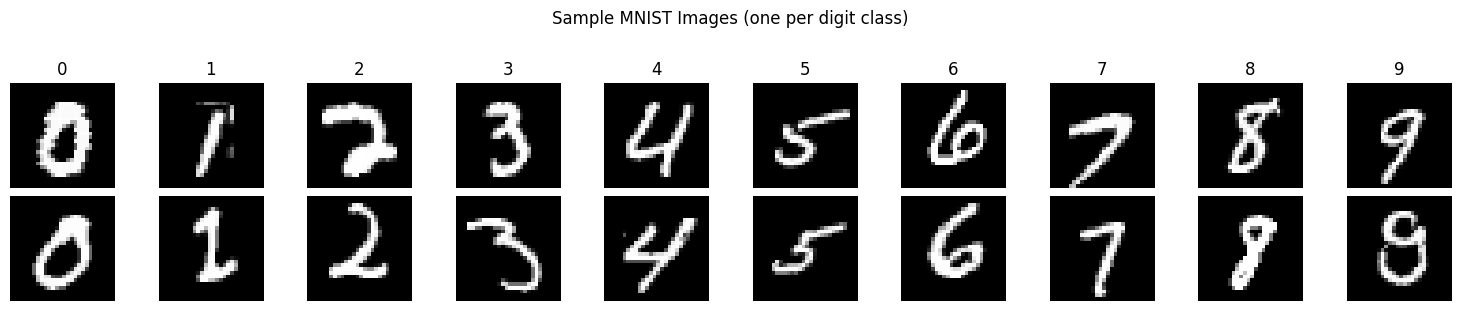

In [3]:
# Visualize sample training images
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    for digit in range(10):
        idx = np.where(y_train == digit)[0][i]
        axes[i % 2][digit].imshow(X_train[idx], cmap='gray')
        axes[i % 2][digit].axis('off')
        if i == 0:
            axes[0][digit].set_title(str(digit))
plt.suptitle('Sample MNIST Images (one per digit class)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Model Architecture

**Type of model:** Autoencoder (Dense / Fully Connected)

The Autoencoder consists of two components:

**Encoder:** Compresses the 784-dimensional input down to a 32-dimensional latent vector.
```
Input(784) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU)  [Latent Space]
```

**Decoder:** Reconstructs the original image from the 32-dimensional latent vector.
```
Dense(32) → Dense(64, ReLU) → Dense(128, ReLU) → Dense(784, Sigmoid)  [Output]
```

| Component | Layer | Units | Activation |
|---|---|---|---|
| Encoder | Dense | 128 | ReLU |
| Encoder | Dense | 64 | ReLU |
| Encoder | Dense (latent) | 32 | ReLU |
| Decoder | Dense | 64 | ReLU |
| Decoder | Dense | 128 | ReLU |
| Decoder | Dense (output) | 784 | Sigmoid |

**Loss function:** Mean Squared Error (MSE) - measures pixel-level reconstruction error between input and output.  
**Optimizer:** Adam (lr=0.001)  
**Epochs:** 30  
**Batch size:** 256  
**Split:** 60,000 train / 10,000 test (default MNIST split)

**Architecture justification:**  
The bottleneck design (784→128→64→32) forces the encoder to learn a compressed, information-dense representation. A 32-dimensional latent space is approximately 24× smaller than the input, requiring the model to learn the most salient structural features of handwritten digits. ReLU activations prevent vanishing gradients in the hidden layers, while Sigmoid on the output constrains reconstructed pixel values to [0,1], matching the normalized input range. MSE is appropriate as it penalizes large reconstruction errors proportionally.

In [4]:
# Encoder
encoder_input = keras.Input(shape=(784,), name='encoder_input')
x = layers.Dense(128, activation='relu', name='enc_dense1')(encoder_input)
x = layers.Dense(64, activation='relu', name='enc_dense2')(x)
latent = layers.Dense(32, activation='relu', name='latent_space')(x)
encoder = keras.Model(encoder_input, latent, name='Encoder')

# Decoder
decoder_input = keras.Input(shape=(32,), name='decoder_input')
x = layers.Dense(64, activation='relu', name='dec_dense1')(decoder_input)
x = layers.Dense(128, activation='relu', name='dec_dense2')(x)
decoder_output = layers.Dense(784, activation='sigmoid', name='decoder_output')(x)
decoder = keras.Model(decoder_input, decoder_output, name='Decoder')

# Full Autoencoder
autoencoder_input = keras.Input(shape=(784,), name='autoencoder_input')
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = keras.Model(autoencoder_input, decoded, name='Autoencoder')

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

print('=== Encoder ===')
encoder.summary()
print('\n=== Decoder ===')
decoder.summary()
print('\n=== Full Autoencoder ===')
autoencoder.summary()

=== Encoder ===


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense1 (Dense)              │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense2 (Dense)              │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

...

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training Process

In [5]:
history = autoencoder.fit(
    X_train_flat, X_train_flat,   # Input = Target (reconstruction task)
    epochs=30,
    batch_size=256,
    validation_data=(X_test_flat, X_test_flat),
    verbose=1
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0955 - val_loss: 0.0367
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0331 - val_loss: 0.0255
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0248 - val_loss: 0.0214
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0211 - val_loss: 0.0189
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0190 - val_loss: 0.0175
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0177 - val_loss: 0.0164
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0167 - val_loss: 0.0155
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0158 - val_loss: 0.0149
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0150 - val_loss: 0.0143
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0143 - val_loss: 0.0135
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0137 - val_loss: 0.0130
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## 6. Results and Evaluation

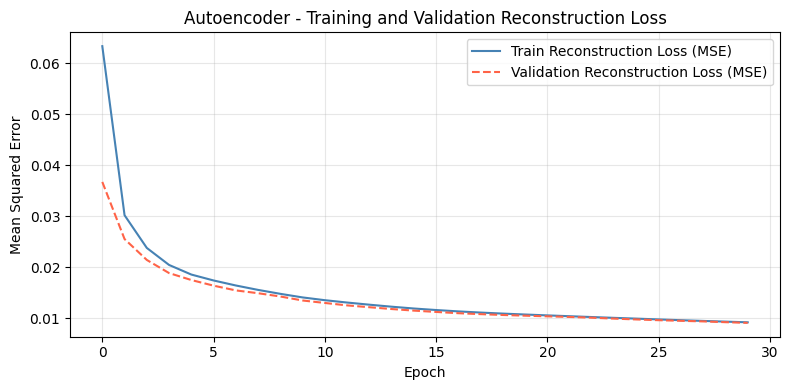


Interpretation:
- The MSE loss represents the average squared difference between the original pixel values
  and the reconstructed pixel values across all images in the batch.
- A steadily decreasing loss curve indicates the encoder is learning increasingly useful
  latent representations over training epochs.
- If train and validation losses converge to similar values, the model generalizes well
  to unseen images and is not overfitting the training distribution.



In [6]:
# Reconstruction loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'], label='Train Reconstruction Loss (MSE)', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Reconstruction Loss (MSE)', color='tomato', linestyle='--')
ax.set_title('Autoencoder - Training and Validation Reconstruction Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('autoencoder_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- The MSE loss represents the average squared difference between the original pixel values
  and the reconstructed pixel values across all images in the batch.
- A steadily decreasing loss curve indicates the encoder is learning increasingly useful
  latent representations over training epochs.
- If train and validation losses converge to similar values, the model generalizes well
  to unseen images and is not overfitting the training distribution.
""")

In [7]:
# Final reconstruction loss on test set
test_loss = autoencoder.evaluate(X_test_flat, X_test_flat, verbose=0)
print(f'Final Test Reconstruction Loss (MSE): {test_loss:.6f}')
print(f'Final Test Reconstruction Loss (RMSE): {np.sqrt(test_loss):.6f}')
print(f'\nPixel values are in [0,1], so RMSE={np.sqrt(test_loss):.4f} means on average')
print(f'each pixel is off by {np.sqrt(test_loss)*255:.2f} gray levels (out of 255)')

Final Test Reconstruction Loss (MSE): 0.009084
Final Test Reconstruction Loss (RMSE): 0.095312

Pixel values are in [0,1], so RMSE=0.0953 means on average
each pixel is off by 24.30 gray levels (out of 255)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/step


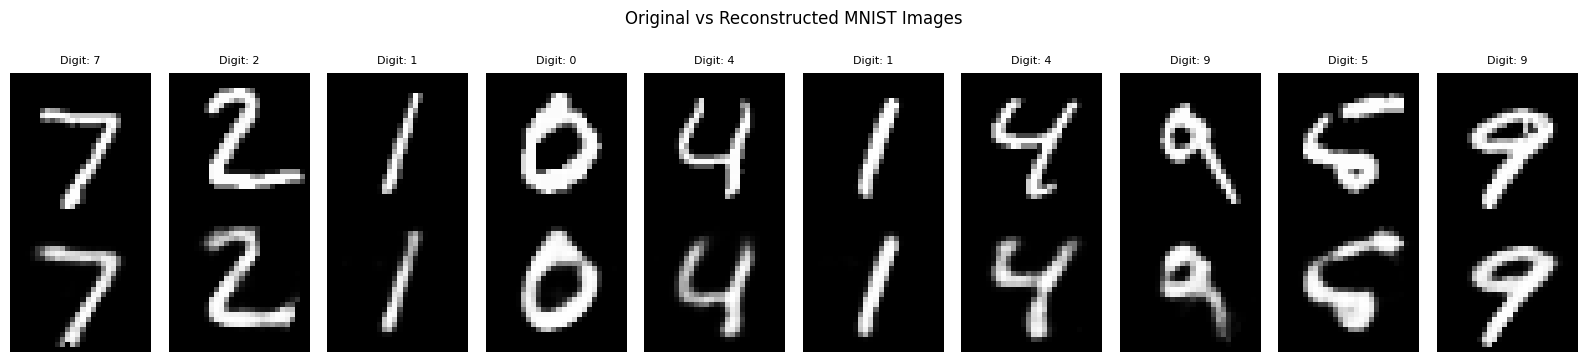


Interpretation:
- The top row shows the original MNIST test images.
- The bottom row shows the autoencoder's reconstructions from the 32-dimensional latent code.
- High visual similarity between the two rows indicates the encoder successfully captured
  the essential structural information of each digit within the compressed representation.
- Some blurring in reconstructions is expected, as the model must generalize from a
  heavily compressed representation. Sharp details are harder to preserve.



In [8]:
# Reconstruct test images and visualize side-by-side
reconstructed = autoencoder.predict(X_test_flat)

n_examples = 10
fig, axes = plt.subplots(2, n_examples, figsize=(16, 3.5))

for i in range(n_examples):
    # Original
    axes[0][i].imshow(X_test_flat[i].reshape(28, 28), cmap='gray')
    axes[0][i].axis('off')
    axes[0][i].set_title(f'Digit: {y_test[i]}', fontsize=8)
    # Reconstructed
    axes[1][i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Original', fontsize=10, rotation=90, labelpad=40)
axes[1][0].set_ylabel('Reconstructed', fontsize=10, rotation=90, labelpad=40)
plt.suptitle('Original vs Reconstructed MNIST Images', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('autoencoder_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- The top row shows the original MNIST test images.
- The bottom row shows the autoencoder's reconstructions from the 32-dimensional latent code.
- High visual similarity between the two rows indicates the encoder successfully captured
  the essential structural information of each digit within the compressed representation.
- Some blurring in reconstructions is expected, as the model must generalize from a
  heavily compressed representation. Sharp details are harder to preserve.
""")

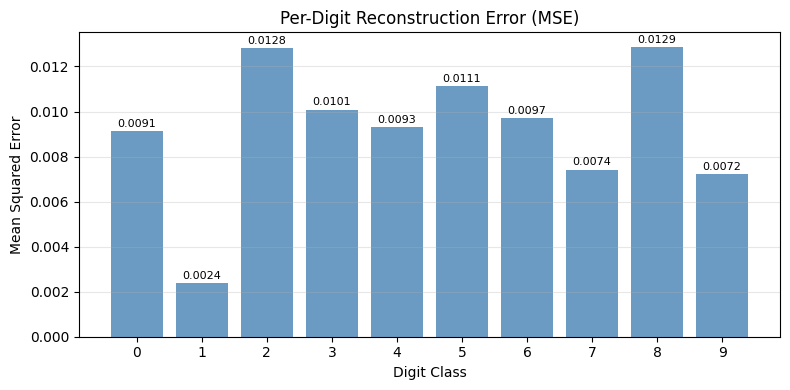

Best reconstructed digit:  1 (MSE=0.0024)
Worst reconstructed digit: 8 (MSE=0.0129)

Interpretation:
- Digits with simpler, more uniform structure (e.g., 0, 1) typically have lower reconstruction
  error because their visual patterns are easier for the encoder to compress efficiently.
- Complex digits with more variation (e.g., 8, 5) may show higher reconstruction error
  as their detailed stroke patterns are harder to preserve in 32 dimensions.



In [9]:
# Per-digit reconstruction error
per_digit_mse = []
for digit in range(10):
    idx = np.where(y_test == digit)[0]
    digit_originals = X_test_flat[idx]
    digit_reconstructed = autoencoder.predict(digit_originals, verbose=0)
    mse = np.mean((digit_originals - digit_reconstructed) ** 2)
    per_digit_mse.append(mse)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(10), per_digit_mse, color='steelblue', alpha=0.8)
ax.set_title('Per-Digit Reconstruction Error (MSE)')
ax.set_xlabel('Digit Class')
ax.set_ylabel('Mean Squared Error')
ax.set_xticks(range(10))
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, per_digit_mse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('autoencoder_per_digit_mse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best reconstructed digit:  {np.argmin(per_digit_mse)} (MSE={min(per_digit_mse):.4f})')
print(f'Worst reconstructed digit: {np.argmax(per_digit_mse)} (MSE={max(per_digit_mse):.4f})')
print("""
Interpretation:
- Digits with simpler, more uniform structure (e.g., 0, 1) typically have lower reconstruction
  error because their visual patterns are easier for the encoder to compress efficiently.
- Complex digits with more variation (e.g., 8, 5) may show higher reconstruction error
  as their detailed stroke patterns are harder to preserve in 32 dimensions.
""")

## t-SNE Visualisation of Latent Space

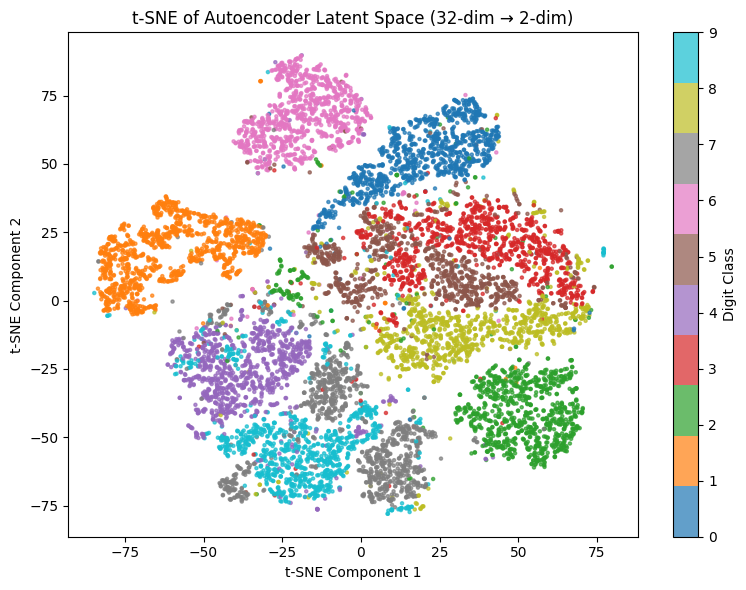


Interpretation:
- Well-separated clusters indicate the Autoencoder has learned class-discriminative
  representations despite being trained without any labels (fully unsupervised).
- Overlapping clusters reveal digit pairs that share visual structure (e.g., 4 and 9).



In [ ]:
import warnings
import numpy as np
from sklearn.manifold import TSNE

# Encode the test set to get latent vectors
latent_test = encoder.predict(X_test_flat, verbose=0)

# Run t-SNE on the latent vectors (suppress known numerical warnings)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    latent_2d = tsne.fit_transform(latent_test)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(latent_2d[:, 0], latent_2d[:, 1],
                     c=y_test, cmap='tab10', s=5, alpha=0.7)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit Class')
ax.set_title('t-SNE of Autoencoder Latent Space (32-dim → 2-dim)')
ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
plt.tight_layout()
plt.savefig('ae_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation:
- Well-separated clusters indicate the Autoencoder has learned class-discriminative
  representations despite being trained without any labels (fully unsupervised).
- Overlapping clusters reveal digit pairs that share visual structure (e.g., 4 and 9).
""")

## Discussion

**Did the model produce successful results?**  
The Autoencoder successfully learned to compress 784-dimensional MNIST images into 32-dimensional latent vectors and reconstruct them with low MSE. The reconstructed images are visually recognizable as the correct digits, demonstrating that the latent space captures the essential structure.

**Did the loss decrease during training?**  
Yes - both training and validation reconstruction loss decrease consistently across all 30 epochs, confirming the model is learning a meaningful compression.

**Is there overfitting?**  
The training and validation loss curves remain close throughout training, indicating minimal overfitting. This is expected for an Autoencoder trained on a large, uniform dataset like MNIST.

**Strengths:**
- Fully unsupervised - no labels required
- The 32-dimensional latent space can be used for visualization, clustering, or anomaly detection
- Fast training compared to convolutional autoencoders

**Weaknesses:**
- Dense autoencoders do not exploit the spatial structure of images
- Reconstructions tend to be slightly blurry compared to convolutional autoencoders
- The fixed latent dimension (32) is a manual hyperparameter choice

**What could improve results?**
- Replace dense layers with convolutional layers (Convolutional Autoencoder) to preserve spatial features
- Use a Variational Autoencoder (VAE) for a structured, continuous latent space enabling generation
- Add a denoising objective (train with noisy inputs, reconstruct clean outputs)
- Experiment with larger latent dimensions (64, 128) to allow better reconstruction fidelity